In [22]:
from typing import Tuple, List

import os
import rootutils

from tqdm import tqdm

rootutils.setup_root(os.path.abspath('./'), indicator=".project-root", pythonpath=True, dotenv=True, cwd=True)

# auto-loading of imports from outside scripts
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from src.utils import create_df, compute_fingerprints, compute_descriptors, create_data, eval_metrics, plot_pred_true, plot_importance
from src.avail_descriptors import descriptors_all, descriptors_short

In [3]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from argparse import Namespace

from sklearn.model_selection import train_test_split

---
# Feature Extraction:

In [4]:
data_path = "data/Bradley_dataset_ok_3"
columns = ['line_number', 'smiles', 'cas', 'label', 'T']

df = create_df(data_path, columns)

In [5]:
data_args = {
    "descriptors": descriptors_all,

    "apply_norm": False,
    
    "create_fingerprints": False,
    "temp_column": True,
}

### Computing Features (load, if already precomputed)

In [6]:
from src.utils import create_or_load_data

In [7]:
X, labels, temp = X_bradley, labels_bradley, temp_bradley = create_or_load_data(df, data_args, 'saved_np_obj/Bradley')

Loading data from saved_np_obj/Bradley


### If you want to simulate NaNs in the temperature:

In [8]:
nan_proba = 0.8

np.random.seed(42)
mask = np.random.choice([True, False], size=temp.shape, p=[nan_proba, 1 - nan_proba])
temp_with_nans = temp.copy()
temp_with_nans[mask] = np.nan

In [9]:
temp = temp_with_nans

In [10]:
labels

array([0, 0, 0, ..., 0, 0, 1])

---
# MultiTask Learning with Lightning:

In [11]:
from src.multitask_nn import MultiTaskModel, create_datasets

from lightning.pytorch.callbacks import Callback, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from lightning import seed_everything, Trainer
from torch.utils.data import DataLoader

from datetime import datetime

In [12]:
seed_everything(42, verbose=False)

42

In [13]:
cfg = Namespace(
    project_name="bradley",
    
    normalize_data=True,
    train_size=0.8,

    batch_size=256,
    lr=1e-3,
    max_epochs=20,

    hid_dim=256,
    depth=5,
    use_residual=True,
    drop=0.3,

    cl_loss_coef=1.,
    pos_label_weight=2,
    reg_loss_coef=1e-4,

    num_workers=0,
    persistent_workers=False,
)

In [14]:
train_data, val_data = create_datasets(X, labels, temp, use_norm=cfg.normalize_data, train_size=cfg.train_size)

# persistent_workers=True reduces overhead of creating workers
train_loader = DataLoader(train_data, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, persistent_workers=cfg.persistent_workers)
val_loader = DataLoader(val_data, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, persistent_workers=cfg.persistent_workers)

In [15]:
input_dim = X.shape[1]
model = MultiTaskModel(
    input_dim=input_dim,

    hidden_dim=cfg.hid_dim,
    depth=cfg.depth,
    use_residual=cfg.use_residual,
    drop=cfg.drop,

    lr=cfg.lr,

    cl_loss_coef=cfg.cl_loss_coef,
    pos_label_weight=cfg.pos_label_weight,
    reg_loss_coef=cfg.reg_loss_coef
)

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

logger = TensorBoardLogger(
    save_dir="tb_logs/", name=cfg.project_name
)

checkpoint_callback = ModelCheckpoint(
    dirpath=f"checkpoints/{cfg.project_name}-{current_date}",
    filename="{epoch:02d}-{val_loss:.4f}",
    save_top_k=1,
    monitor="V_tot",
    mode="min",
    save_last=True,
)

trainer = Trainer(
    logger=logger,
    callbacks=[checkpoint_callback],
    max_epochs=cfg.max_epochs,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [16]:
trainer.fit(model, train_loader, val_loader)


  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | shared       | Sequential        | 289 K  | train
1 | classifier   | Sequential        | 66.0 K | train
2 | regressor    | Sequential        | 66.0 K | train
3 | val_accuracy | BinaryAccuracy    | 0      | train
4 | val_f1       | BinaryF1Score     | 0      | train
5 | val_roc_auc  | BinaryAUROC       | 0      | train
6 | val_r2_class | R2Score           | 0      | train
7 | val_mse      | MeanSquaredError  | 0      | train
8 | val_mae      | MeanAbsoluteError | 0      | train
9 | val_r2_reg   | R2Score           | 0      | train
-----------------------------------------------------------
421 K     Trainable params
0         Non-trainable params
421 K     Total params
1.687     Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/avarlamov/phase-prediction/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/avarlamov/phase-prediction/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


### Doing T(distance) plot:

In [49]:
def plot_T_from_distance(model, val_loader, threshold=0.5):
    result_logits, result_reg = [], []

    for batch in tqdm(val_loader, desc="Computing T(distance) plot"):
        class_logits, reg_output = model(batch[0])
        result_logits.append(class_logits.detach().cpu().numpy())
        result_reg.append(reg_output.detach().cpu().numpy())

    result_logits = np.concatenate(result_logits).flatten()
    result_reg = np.concatenate(result_reg).flatten()

    # Apply sigmoid to get probabilities
    probs = 1 / (1 + np.exp(-result_logits))
    # Get predicted classes (1 if prob > 0.5, else 0)
    pred_classes = (probs > 0.5).astype(int)

    # Plot with different colors for each class
    plt.figure(figsize=(10, 6))
    
    # Colors and linear regression for each class
    for name, cls, color in [('Liquid', 0, 'blue'), ('Solid', 1, 'red')]:
        mask = pred_classes == cls
        
        # Plot scatter points
        plt.scatter(
            result_logits[mask], result_reg[mask], 
            c=color, 
            label=name,
            alpha=0.7
        )
        
        # Perform linear regression for this class
        if np.sum(mask) > 1:  # Need at least 2 points for regression
            x = result_logits[mask]
            y = result_reg[mask]
            slope, intercept = np.polyfit(x, y, 1)
            
            # Plot regression line
            x_range = np.array([min(x), max(x)])
            plt.plot(x_range, slope * x_range + intercept, 
                     color=color, linestyle='--', 
                     label=f'{name} fit: {slope:.2f}x + {intercept:.2f}')
            
    plt.ylabel('Temperature, C')
    plt.xlabel('Distance to separating plane')
    plt.grid(alpha=0.3)
    
    plt.legend()
    plt.show()


Computing T(distance) plot: 100%|██████████| 21/21 [00:00<00:00, 106.49it/s]


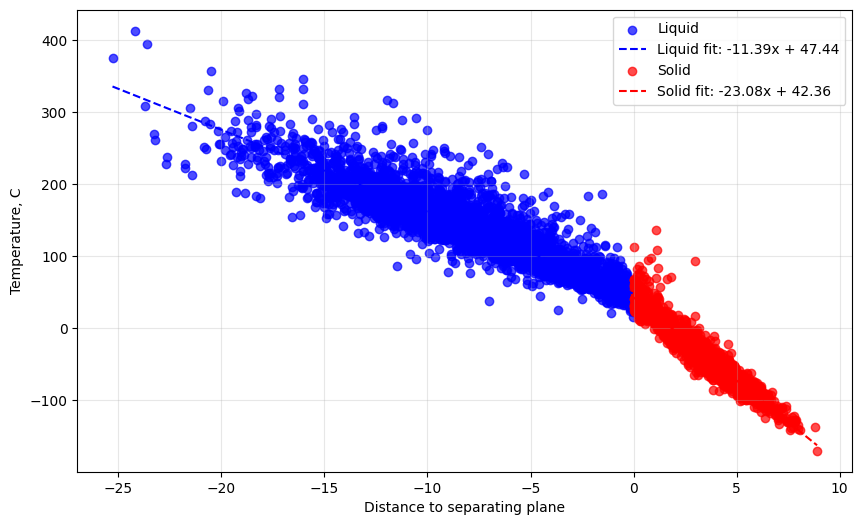

In [50]:
plot_T_from_distance(model, val_loader)

---
# Comparing to catboost:

In [17]:
raise Exception("stop")

Exception: stop

In [51]:
from catboost import CatBoostClassifier, CatBoostRegressor
from src.utils import eval_metrics

In [52]:
X_train, X_val, y_train, y_val, temp_train, temp_val = train_test_split(X, labels, temp, train_size=cfg.train_size)

In [68]:
temp_train[0] + 2

nan

In [65]:
temp_train[temp_train == np.nan]

array([], dtype=float64)

In [62]:
catboost_reg = CatBoostRegressor(
    # iterations=1000,
    # depth=10,
    # learning_rate=0.01,
    verbose=100,
)

catboost_reg.fit(X_train, temp_train)
temp_pred = catboost_reg.predict(X_val)

CatBoostError: catboost/libs/metrics/metric.cpp:6951: metric/loss-function RMSE do not allows nan value on target

In [ ]:
eval_metrics(temp_val, temp_pred, type="regression")

{'MSE': 1516.2543538150444,
 'MAE': 28.737816869766924,
 'R2': 0.8420226543181508}

In [108]:
catboost_cl = CatBoostClassifier(
    # iterations=1000,
    # depth=10,
    # learning_rate=0.01,
    verbose=100,
)

catboost_cl.fit(X_train, y_train)
y_pred = catboost_cl.predict(X_val)

Learning rate set to 0.03749
0:	learn: 0.6515868	total: 5.48ms	remaining: 5.47s
100:	learn: 0.1933913	total: 613ms	remaining: 5.46s
200:	learn: 0.1729390	total: 1.25s	remaining: 4.97s
300:	learn: 0.1592423	total: 1.82s	remaining: 4.23s
400:	learn: 0.1472013	total: 2.42s	remaining: 3.62s
500:	learn: 0.1376692	total: 2.99s	remaining: 2.98s
600:	learn: 0.1298362	total: 3.68s	remaining: 2.44s
700:	learn: 0.1229117	total: 4.27s	remaining: 1.82s
800:	learn: 0.1167859	total: 4.85s	remaining: 1.21s
900:	learn: 0.1108378	total: 5.43s	remaining: 597ms
999:	learn: 0.1054667	total: 6s	remaining: 0us


In [109]:
eval_metrics(y_val, y_pred, type="classification")

{'ACC': 0.9429015342785007,
 'F1': 0.8754237288135593,
 'BAL-ACC': 0.9117787305212628,
 'ROC-AUC': 0.9117787305212628,
 'R2': 0.6825682471369816}